# Computational Social Science Project #3 

**Enter your Name:** Vo Ram Yoon

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [1]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer
from matplotlib import pyplot

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV


In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [3]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [4]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

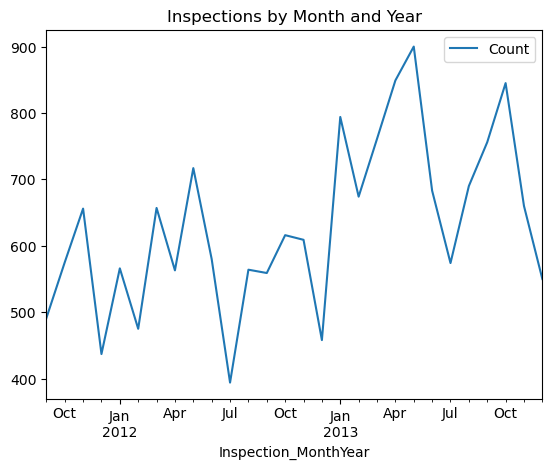

In [7]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 
plt.show()

Let's visualize what the distribution of results looks like.

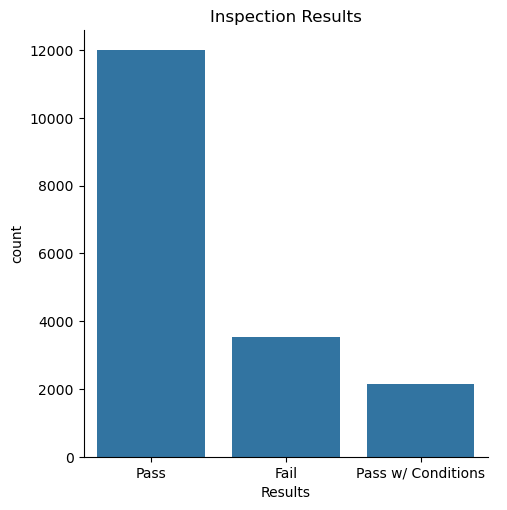

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

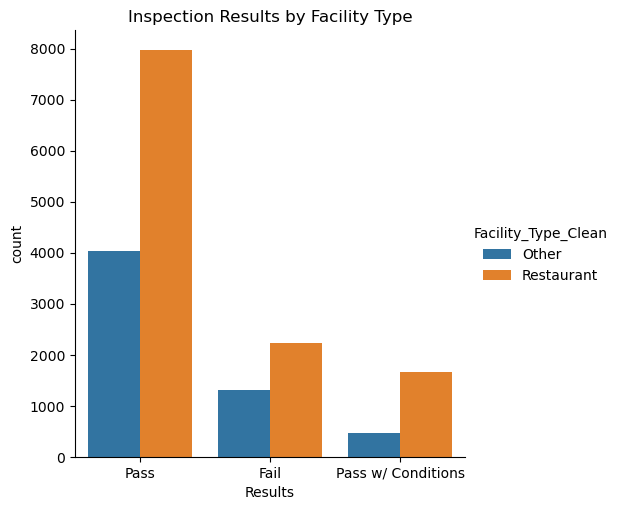

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X = pd.get_dummies(X)

In [12]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Data Splitting

In [13]:
# Set seed
np.random.seed(10)

# training and test split 
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    train_size = .80, 
                                                    test_size=0.20,
                                                    stratify=y)


I will just be splitting the data into train and test sets since the cross-validation process will create its own validation sets.

### Model 1: Logistic Regression

Assuming that the outcome is binary, a logistic model provides the probability of an observation belonging to one of two groups. It assumes that the relationship between the observation and outcome is linear, so it doesn't do as well with non-linear relationships. However, logits can be interpreted as probabilities, which makes this model easy to understand for general audiences. A logistic regression is an appropriate choice for this problem since I am trying to predict whether a facility passed or failed its inspection.

In [14]:

# create a model
logit_reg = LogisticRegression(max_iter=1000)

# set parameters
param_grid = {'penalty': ['l1', 'l2'],
             'C': np.arange(.1, 1, .1),
             'fit_intercept': [True, False],
             'solver': ['liblinear']}


# execute the grid search and fit to training data

#RandomizedSearch was used over GridSearch so that the run time wouldn't take so long. When I was originally doing GridSearch,
#running the three models altogether took almost an hour.
logit_grid = RandomizedSearchCV(logit_reg, 
                          param_grid, 
                          cv=3,
                          n_jobs=-1)

# fit the model
logit_model = logit_grid.fit(X_train, y_train.ravel())


# choose best performing model
best_logit_model = logit_grid.best_estimator_



###  Model 2: Random Forest

A random forest aggregates the results of many decision trees, using a subset of features to grow each tree. With each tree making a prediction, random forest enables one to learn from multiple trees and go with the majority in a classification problem. The pros of this model are that random forests handle non-linear relationships better than logistic models, are better at handling complex datasets with different kinds of data, and are less likely to overfit by averaging across multiple trees. However, some cons are that less interpretable and more computationally intensive. Random forests may be an appropriate choice for this problem since the relationship between the features of facilities and their inspection results might not be linear.

In [15]:
# Base model
rf = RandomForestClassifier(random_state=7)

# Define param distribution
param_dist = {
    'n_estimators': [100, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}


# Grid search
randomforest_grid = RandomizedSearchCV(
    estimator=rf,
    n_iter=30,
    param_distributions=param_dist,
    cv=3,
n_jobs=-1)

#fit the model
rf_model = randomforest_grid.fit(X_train, y_train.ravel())

# choose best performing model
best_rf_model = randomforest_grid.best_estimator_


### Model 3: XGBoost

Similarly to AdaBoost and Gradient Boosting, XGBoost makes predictions by using decision trees with each subsequent model addressing the errors created by previous models. It is also able to account for non-linear relationships. One pro of XGBoost is that it prevents overfitting more effectively through added regularization techniques. Other benefits of XGBoost compared to AdaBoost and Gradient Boosting is that it can handle missing values and includes optimization techniques that make it faster. Some cons are that it is computationally intensive and performance is sensitive to hyperparameter tuning. XGBoost may be an appropriate choice for this problem since it is effective at dealing with classification problems, especially those that involve non-linear relationships.

In [16]:
#initializing an XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=10)

# defining param distribution
param_dist = {
    'n_estimators': [100, 400],
    'max_depth': [3, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.4, 0.8],
    'colsample_bytree': [0.4, 0.8],
    'min_child_weight': [1, 5],
    'gamma': [0, 0.1, 0.3]
}

#grid search
xgb_grid = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
n_jobs=-1)

#fitting the model
xgb_model = xgb_grid.fit(X_train, y_train.ravel())

# choose best performing model
best_xgb_model = xgb_grid.best_estimator_


### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [28]:
# defining models I want compared
models = {
    "Logistic Regression": best_logit_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_xgb_model
}

# defining metrics
scorers = {
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score),
    "Recall": make_scorer(recall_score),
    "F1": make_scorer(f1_score)
}

# looping through models and metrics
for model_name, model in models.items():
    print(f"\nModel: {model_name}")
    for metric_name, scorer in scorers.items():
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring=scorer)
        print(f"{metric_name}: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")



Model: Logistic Regression
Accuracy: 0.921 (+/- 0.003)
Precision: 0.779 (+/- 0.016)
Recall: 0.851 (+/- 0.037)
F1: 0.812 (+/- 0.011)

Model: Random Forest
Accuracy: 0.927 (+/- 0.003)
Precision: 0.778 (+/- 0.008)
Recall: 0.891 (+/- 0.024)
F1: 0.830 (+/- 0.009)

Model: XGBoost
Accuracy: 0.924 (+/- 0.004)
Precision: 0.778 (+/- 0.001)
Recall: 0.874 (+/- 0.026)
F1: 0.823 (+/- 0.011)


Among the four validation metrics of accuracy, recall, precision, and f1score, I would be prioritizing the f1score since it balances both precision and recall. In the case of accurately classifying restaurants and other facilities that passed or failed their inspections, high precisions entails fewer false positives (i.e., mistakenly failing restaurants and facilities) while high recall entails fewer false negatives (i.e., mistakenly passing restaurants and facilities that actually failed). The former is more fair to businesses while the latter is safer for the general public. Therefore, the f1score allows us to balance both needs and also takes into account the fact that it is far more common for restaurants and other facilities to pass their inspections, which is an imbalanced ratio that might present a model as being more effective than it actually is when it just leans towards predicting passed inspections.

## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

Based on the coefficient and feature importance plots for the three models, it seems that "seriousCount" is by far the most influential feature on my predictions across all models. The random forest and XGBoost models also identified "minorCount" as the second or third most influential feature. Other commonly shared features by at least two of the three models are "Risk 2 (Medium)", "firstRecord", and "pastFail". I wish that the "seriousCount" feature were disaggregated into different kinds of counts that might have led a restaurant or other kind of facility that serves food to fail its inspection. It would also be useful to have a feature that rates the quality of food safety training provided to employees or tracks the percentage of employees who hold a certificate on food safety. In addition, it would be interesting to also have a column that categorizes facilities by whether they are part of a corporate chain or an independent/locally-owned business to see if the quality of food safety practices differ between the two.

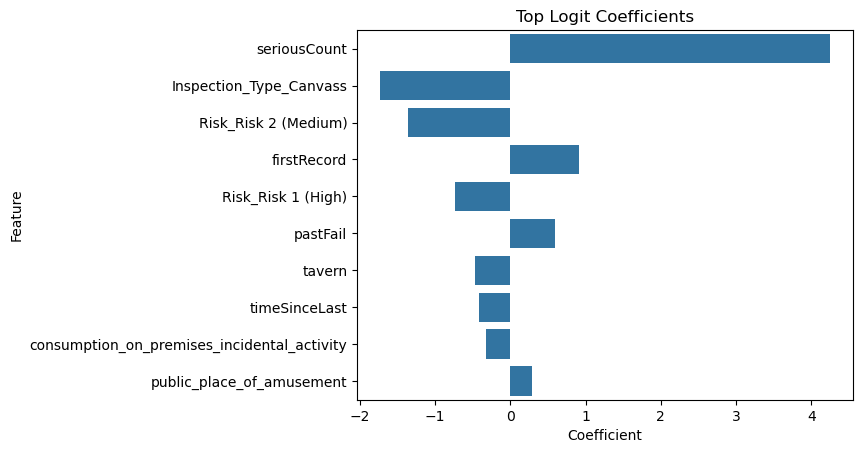

In [18]:
### making a plot of top logit coefficients

# extract the coefficents and create a dataframe for plotting 
logit_data = pd.concat([pd.DataFrame(X.columns),
                        pd.DataFrame(np.transpose(best_logit_model.coef_))],
                       axis = 1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

# plot 
sns.barplot(x="Coefficient", 
            y="Feature", 
            data=logit_data.nlargest(10, 'abs_coef')).set_title("Top Logit Coefficients")
plt.show()



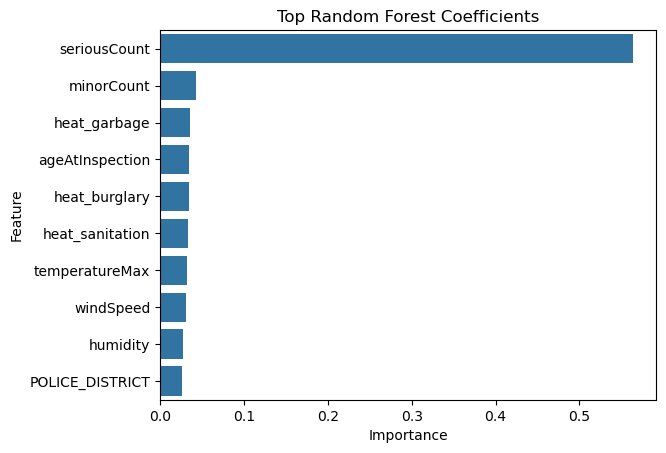

In [19]:
### making a feature importance plot for random forest

# create feature importance dataframe
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(best_rf_model.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot 
sns.barplot(x = "Importance", 
            y = "Feature", 
            data = feat_importances.nlargest(10, 'Importance')).set_title("Top Random Forest Coefficients") # identify the 10 most important features
plt.show()



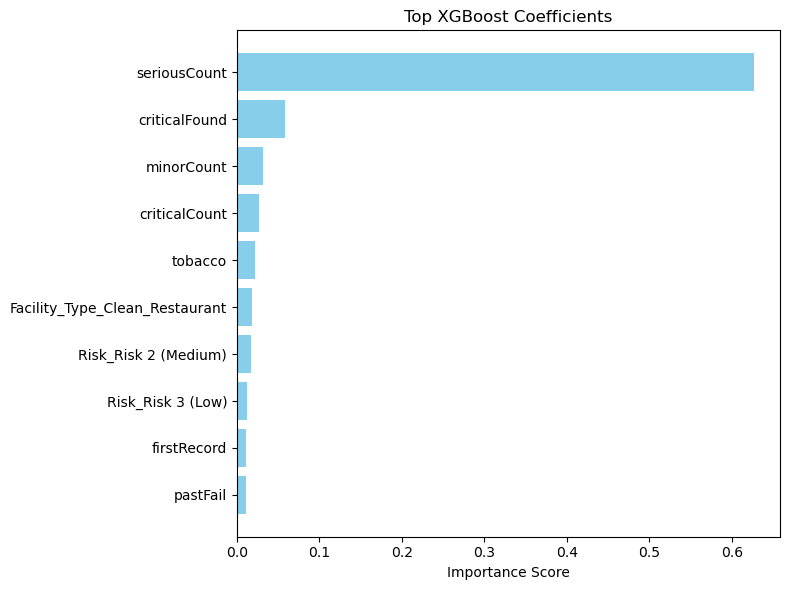

In [20]:
### making a feature importance plot for XGBoost

# Get feature importances
importances = best_xgb_model.feature_importances_

# Get feature names (if available)
feature_names = best_xgb_model.get_booster().feature_names

# Create a DataFrame for sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.xlabel('Importance Score')
plt.title('Top XGBoost Coefficients')
plt.tight_layout()
plt.show()


### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [21]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.

# prediction to test data
xgb_pred = best_xgb_model.predict(X_test)

# predict probabilities for XGBoost
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]

In [22]:
#
# 2. Order your audits by their probability of detecting a "Fail" score

X_test_order = X_test.copy()
X_test_order['True_Result'] = y_test
X_test_order['Fail_Prob'] = xgb_probs

# Sort by highest probability of failure
ordered_audits = X_test_order.sort_values(by='Fail_Prob', ascending=False)

ordered_audits.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW,True_Result,Fail_Prob
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1335972,ROTHSCHILD LIQUORS,1,3,3,0,0,0,0,2.000000,1,11.0,11.068493,0,1,0,0,0,1,0,0,0,0,0,0,0.001407,64.040000,8.603333,0.613333,19.570288,39.479458,37.732965,1,False,False,True,True,True,False,False,False,False,True,1,0.995571
1336114,COLLETTI'S RESTAURANT,3,3,7,1,0,1,4,0.539726,0,16.0,11.087671,0,0,0,0,0,0,0,0,0,0,0,0,0.009797,74.463333,9.116667,0.710000,0.152282,10.262204,19.960127,1,True,False,False,True,False,True,False,False,False,True,1,0.993740
545800,JUDI'S SPORTS BAR & GRILL,0,3,7,0,0,0,0,2.000000,1,5.0,9.221918,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,48.316667,9.103333,0.780000,42.866545,45.889055,5.851505,0,True,False,False,True,False,True,False,False,False,True,1,0.993380
1227971,PETE'S MEAT & GROCERY#2,1,3,3,0,0,0,5,0.715068,0,7.0,7.583562,0,1,0,0,0,1,0,0,0,0,0,0,0.012953,68.636667,14.316667,0.750000,27.861465,50.178109,33.386521,1,False,True,False,True,True,False,False,False,False,True,1,0.992716
1227535,GEORGIS CATERING,2,3,8,0,0,0,6,0.906849,0,8.0,10.542466,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,80.423333,6.026667,0.636667,18.175837,11.849360,22.793878,1,True,False,False,True,False,True,False,False,False,True,1,0.992527


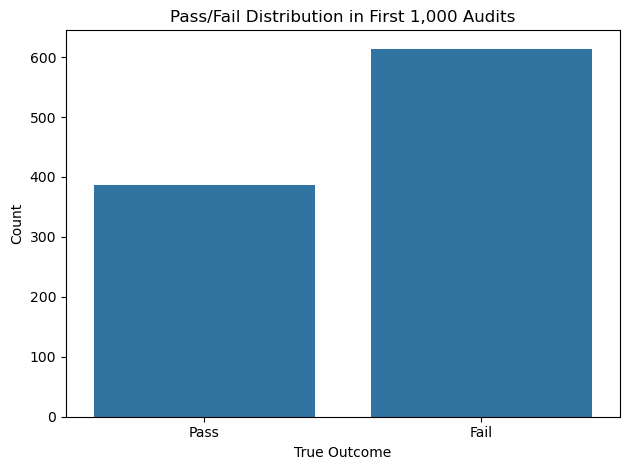

In [23]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset

first_1000 = ordered_audits.head(1000)

sns.countplot(data=first_1000, x='True_Result')
plt.title('Pass/Fail Distribution in First 1,000 Audits')
plt.xlabel('True Outcome')
plt.ylabel('Count')
plt.xticks([0, 1], ['Pass', 'Fail'])
plt.tight_layout()
plt.show()


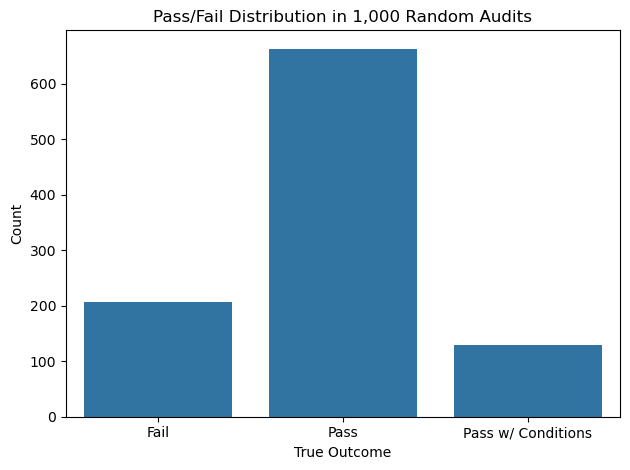

In [24]:
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

random_audits = chicago_inspections_2011_to_2013.sample(n=1000, random_state=7) 

sns.countplot(data=random_audits, x="Results")
plt.title('Pass/Fail Distribution in 1,000 Random Audits')
plt.xlabel('True Outcome')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [24]:
#checking column names

chicago_inspections_2014.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pastFail', 'pastCritical', 'pastSerious', 'pastMinor', 'timeSinceLast',
       'firstRecord', 'ID', 'LICENSE_ID', 'ACCOUNT_NUMBER', 'LEGAL_NAME',
       'DOING_BUSINESS_AS_NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP_CODE',
       'WARD', 'PRECINCT', 'WARD_PRECINCT', 'POLICE_DISTRICT', 'LICENSE_CODE',
       'LICENSE_DESCRIPTION', 'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY',
       'LICENSE_NUMBER', 'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods', 'outdoor_patio', 'public_place_of_amusement

In [25]:
# data processing

# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2014.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE'],
                                     inplace = True)

# set index
chicago_inspections_2014.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

#dropping time-related data
chicago_inspections_2014 = chicago_inspections_2014.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate'],
                                                                                  axis = 1)


# process features
X_test2014 = chicago_inspections_2014.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

X_test2014 = pd.get_dummies(X_test2014)

# process target 
y_test2014 = chicago_inspections_2014['Results']

#binarizing outcome variable
y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y_test2014 = lb_style.fit_transform(y_test2014)

# recode 0s and 1s so 1s are "Fail"
y_test2014 = np.where(y_test2014 == 1, 0 ,1)



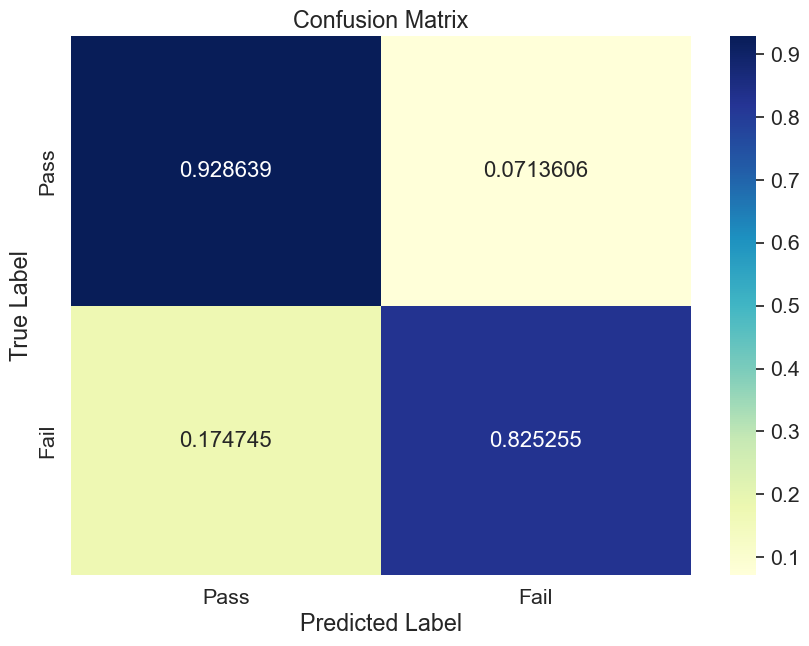

In [26]:
# predict and compare 
# -----------

xgb_pred_2014 = best_xgb_model.predict(X_test2014)

# create a confusion matrix
cf_matrix = confusion_matrix(y_test2014, 
                             xgb_pred_2014, 
                             normalize = "true")

# convert to a dataframe
df_cm = pd.DataFrame(cf_matrix, range(2), range(2))

# set figure specifications
df_cm = df_cm.rename(index=str, columns={0: "Pass", 1: "Fail"})
df_cm.index = ["Pass", "Fail"]
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(df_cm, 
           annot=True,
           annot_kws={"size": 16},
           fmt='g',
        cmap="YlGnBu",
           cbar = True)

# plot
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [27]:
# evaluate
# -----------

acc = accuracy_score(y_test2014, xgb_pred_2014)
prec = precision_score(y_test2014, xgb_pred_2014, pos_label=1)   # change pos_label if needed
rec = recall_score(y_test2014, xgb_pred_2014, pos_label=1)
f1 = f1_score(y_test2014, xgb_pred_2014, pos_label=1)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")



Accuracy:  0.9081
Precision: 0.7420
Recall:    0.8253
F1 score:  0.7814


## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


Accuracy does not take into account that there might be an imbalance in the data such that one result is exceedingly common compared to the other, so a model that consistently predicts the most common result will have high accuracy even if it consistently fails to predict the other result. In addition, accuracy treats false positives and false negatives equally. In public policy and the social sciences, one might prefer to lower the chances of a false positive or false negative depending on the societal consequences and cost of resources of each. For instance, reducing false negatives by maximizing recall would be preferable in cases in which overooking failed inspections for critical infrastructure could have deadly consequences to the general public. Reducing false positives by maximizing precision would be preferable in cases where it would be harmful to an innocent person if they were labeled to be a criminal.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

Policymakers could randomly inspect a certain proportion of restaurants and other food-serving facilities, so that their true hygiene conditions and food safety handling practices will be revealed. In collaboration with data scientists, policymakers could also identify which features can be easily manipulated compared to others and have the algorithm weigh more heavily features that are less easily manipulated. Policymakers can also try to enforce penalties for establishments that misreport their practices while rewarding establishments that are consistent in having high food safety standards without resorting to sudden changes to "gamify" the algorithm.